# 0.准备包

In [1]:
import os
import typing
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
import math
import scipy.stats
from scipy.stats import gaussian_kde, variation
from scipy.stats import pearsonr
import sys
from PIL import Image

In [2]:
import pickle

In [3]:
%matplotlib inline
default_pal = sns.color_palette()
from scipy.stats import gaussian_kde, pearsonr

In [4]:
%config InlineBackend.figure_format = 'retina'
from scipy import stats
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.patches as patches

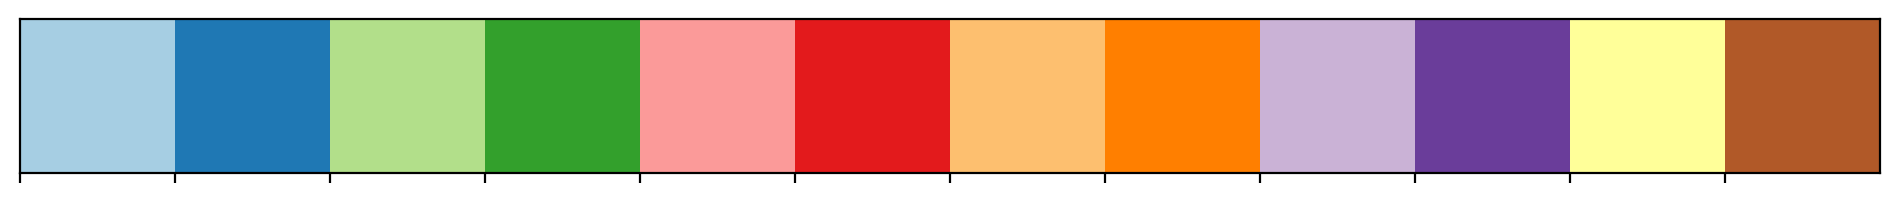

In [5]:
# setting color palette
import seaborn as sns
pal = sns.color_palette('Paired')
#pal = [pal[i] for i in (0,1, 6,7, 8 ,9,2 ,3)]
#pal = [pal[i] for i in (1, 7, 9 ,3)]
sns.set_palette(pal)
sns.palplot(pal)


# 1.基因组上的reads的non-A

## 1.1 测试

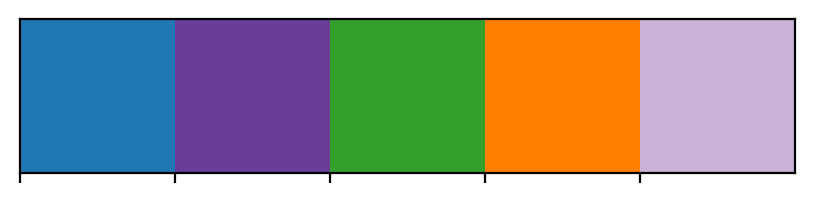

In [12]:
import seaborn as sns
pal = sns.color_palette('Paired')
#pal = [pal[i] for i in (0,1, 6,7, 8 ,9,2 ,3)]
pal = [pal[i] for i in (1, 9, 3, 7 , 8)]
sns.set_palette(pal)
sns.palplot(pal)

In [23]:
total_nona_count = pd.read_csv("/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/01.cucumber/merge.read_info.merged.nonA.peter.txt", sep="\t")

/tmp/ipykernel_31152/3939809704.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  total_nona_count = pd.read_csv("/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/01.cucumber/merge.read_info.merged.nonA.peter.txt", sep="\t")


In [25]:
total_nona_count.columns

Index(['read_core_id', 'chr', 'read_exon_total_num', 'mRNA', 'mRNA_intron_num',
       'mRNA_start', 'mRNA_end', 'retention_introns', 'primer_type',
       'polya_start_raw', 'polya_end_raw', 'polya_start_base',
       'polya_end_base', 'polya_length', 'init_polya_start_base',
       'init_polya_end_base', 'init_polya_length', 'type', 'readname', 'sense',
       'polytail', 'additional_tail', 'adapter', 'dist_adapter',
       'coords_in_read', 'comment', 'A_tail_A', 'A_tail_T', 'A_tail_G',
       'A_tail_C', 'A_tail_pct_A', 'A_tail_pct_T', 'A_tail_pct_G',
       'A_tail_pct_C', 'add_tail_A', 'add_tail_T', 'add_tail_G', 'add_tail_C',
       'add_tail_pct_A', 'add_tail_pct_T', 'add_tail_pct_G', 'add_tail_pct_C'],
      dtype='object')

In [26]:
count_C = (total_nona_count["add_tail_pct_C"] > 70).sum()
count_G = (total_nona_count["add_tail_pct_G"] > 70).sum()
count_U = (total_nona_count["add_tail_pct_T"] > 70).sum()

In [28]:
count_C, count_G, count_U

(15608, 31762, 160996)

In [29]:
total_nona_count=total_nona_count[total_nona_count["polya_length"] > 10]

In [11]:
def classify_nonA_type(row):
    additional_tail = row["additional_tail"]
    
    if pd.isna(additional_tail):  # 避免 NaN 值导致错误
        return np.nan
    
    # 计算不同碱基的个数
    count_C = additional_tail.count("C")
    count_G = additional_tail.count("G")
    count_T = additional_tail.count("T")

    # 根据规则赋值
    if row["add_tail_pct_C"] > 70:
        if count_C > 5:
            return ">5C"
        return f"{count_C}C"
    
    if row["add_tail_pct_G"] > 70:
        if count_G > 5:
            return ">5G"
        return f"{count_G}G"
    
    if row["add_tail_pct_T"] > 70:
        if count_T > 5:
            return ">5U"
        return f"{count_T}U"
    
    return np.nan  # 若无符合条件者，保持 NaN

In [38]:
total_nona_count["nonA-type"] = total_nona_count.apply(classify_nonA_type, axis=1)


/tmp/ipykernel_31152/3335021834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_nona_count["nonA-type"] = total_nona_count.apply(classify_nonA_type, axis=1)


In [12]:
def assign_final_nonA_type(nonA_type):
    if pd.isna(nonA_type) or nonA_type == "":  # 任何 NaN 或 空字符串
        return "A-tail"  # 默认设为 A-tail
    if nonA_type.endswith("G"):
        return "G-tail"
    if nonA_type.endswith("C"):
        return "C-tail"
    if nonA_type.endswith("U"):
        return "U-tail"
    return "A-tail"  # 其他所有情况都返回 A-tail


In [ ]:
# 应用到 DataFrame
total_nona_count["final-nonA-type"] = total_nona_count["nonA-type"].apply(assign_final_nonA_type)
total_nona_count["final-nonA-type"] = total_nona_count["final-nonA-type"].fillna("A-tail")


In [64]:
# 计算 total_nona_count 中 final-nonA-type 为 G-tail, C-tail, U-tail 的比例
total_rows = len(total_nona_count)  # 总行数

# 统计各类型的行数
count_G_tail = (total_nona_count["final-nonA-type"] == "G-tail").sum()
count_C_tail = (total_nona_count["final-nonA-type"] == "C-tail").sum()
count_U_tail = (total_nona_count["final-nonA-type"] == "U-tail").sum()

# 计算占比
ratio_G_tail = count_G_tail / total_rows
ratio_C_tail = count_C_tail / total_rows
ratio_U_tail = count_U_tail / total_rows

# 输出3列值
ratio_G_tail, ratio_C_tail, ratio_U_tail

(0.01309417963478229, 0.007414189006631396, 0.05874470040216338)

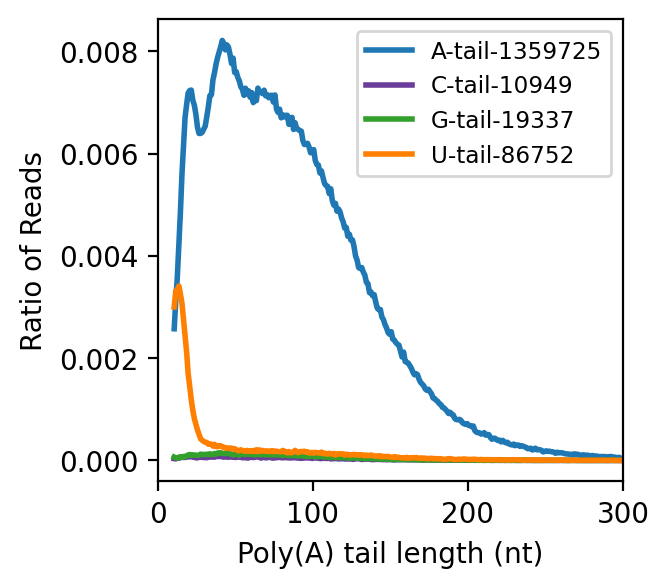

In [63]:
    ##2.看看AUGC结尾的咋样
    grouped_data = total_nona_count.groupby('final-nonA-type')
    fig, ax = plt.subplots(figsize=[3, 3])  # 调整图形大小以清晰显示
    bin_length = 1
    min_length = 10
    max_length = 300
    num_bins = np.arange(min_length, max_length, bin_length)
    
    # 计算整体直方图的归一化系数
    all_values = np.histogram(total_nona_count['polya_length'], bins=num_bins)
    norm_factor = np.sum(all_values[0] * np.diff(all_values[1]))
    
    # 绘制每个组的归一化直方图
    for i, (group, data) in enumerate(grouped_data):
        counts, _ = np.histogram(data['polya_length'], bins=num_bins)
        # 归一化直方图的计数
        norm_counts = counts / norm_factor
        # 找到bin的中心点
        bin_centers = 0.5 * (num_bins[:-1] + num_bins[1:])
        # 绘制归一化的直方图
        ax.plot(bin_centers, norm_counts, label=f"{group}-{len(data)}", color=pal[i], linewidth=2)
    
    ax.set_xlabel('Poly(A) tail length (nt)')
    ax.set_ylabel('Ratio of Reads')
    ax.set_xlim([0, 300])
    ax.legend(fontsize='small')
    plt.title("")
    #plt.savefig(f"/data/Zhaijx/cheny/project/04.polyA_evo/09.non_A/figure/02.last_augc/{sample_new}.png", dpi=300,bbox_inches='tight')
    plt.show()

# 2 全部物种的polya长度

## 2.1 非A尾巴分布

In [173]:
data_folder="/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/"
samples = pd.read_csv('/data/Zhaijx/cheny/project/04.polyA_evo/03.stat/sample_species.txt', sep='\t', 
                    comment='#',header=None, names=['sample', 'sample_name', 'gene_number','sample_new',"peak01","peak02","cp","mt"])

In [9]:
def extract_name(sample):
    parts = sample.split()  # 按空格切分
    if len(parts) >= 2:
        return parts[0][0] + parts[1][:2]  # 取第一个单词的首字母 + 第二个单词的前2个字符
    elif len(parts) == 1:
        return parts[0][0]  # 如果只有一个单词，就取首字母
    else:
        return ''  # 处理空值


In [ ]:

# 应用到数据框
samples['short_name'] = samples['sample_name'].apply(extract_name)

In [175]:
samples

,sample,sample_name,gene_number,sample_new,peak01,peak02,cp,mt,short_name
0,01.cucumber,Cucumis sativus,22491,16.cucumber,20,45,NC_007144.1,NC_016005.1,Csa
1,02.phalaenopsis,Phalaenopsis equestris,20970,09.phalaenopsis,20,45,NC_017609.1,-,Peq
2,03.chlamydomonas,Chlamydomonas reinhardtii,17742,01.chlamydomonas,40,65,NC_005353.1,NC_001638.1,Cre
3,04.adiantum,Adiantum caplillusveneris,31244,04.adiantum,20,45,NC_004766.1,-,Aca
4,05.physcomitrium,Physcomitrium patens,22457,02.physcomitrium,20,45,NC_005087.1,NC_007945.1,Ppa
5,07.selaginella,Selaginella moellendorffii,35448,03.selaginella,20,45,NC_013086.1,-,Smo
6,08.macadamia,Macadamia integrifolia,32433,12.macadamia,20,45,NC_025288.1,NC_058888.1,Min
7,09.nymphaea,Nymphaea colorata,21850,07.nymphaea,20,45,NC_057562.1,NC_037468.1,Nco
8,10.solanum,Solanum lycopersicum,28468,20.solanum,20,45,NC_007898.3,NC_035963.1,Sly
9,11.lactuca,Lactuca sativa,42123,21.lactuca,20,45,NC_007578.1,NC_042756.1,Lsa


In [ ]:

for i, row in samples.iterrows():
    sample, sample_name, gene_number,sample_new, peak01,  peak02,  cp,  mt,short_name = row.values
    data_file_path = os.path.join(data_folder, sample,"/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/")
    total_nona_count = pd.read_csv(data_file_path, sep="\t", na_values="NA")
    total_nona_count=total_nona_count[total_nona_count["polya_length"] > 10]
    total_nona_count["nonA-type"] = total_nona_count.apply(classify_nonA_type, axis=1)
    
    # 应用到 DataFrame
    total_nona_count["final-nonA-type"] = total_nona_count["nonA-type"].apply(assign_final_nonA_type)
    total_nona_count["final-nonA-type"] = total_nona_count["final-nonA-type"].fillna("A-tail")
    nonA_type_counts = total_nona_count['nonA-type'].value_counts().reset_index()
    nonA_type_counts.columns = ['nonA-type', 'count']
    
    df1 = total_nona_count['nonA-type'].value_counts(dropna=False).reset_index()
    df1.columns = ['type', 'count']        # 改列名
    df1['ratio'] = df1['count'] / len(total_nona_count)  # 计算占比
    
    # 2）对 'final-nonA-type' 列分组统计
    df2 = total_nona_count['final-nonA-type'].value_counts(dropna=False).reset_index()
    df2.columns = ['type', 'count']
    df2['ratio'] = df2['count'] / len(total_nona_count)

    # 3）将两份结果在行的方向纵向拼接（不加新列区分来源）
    result = pd.concat([df1, df2], ignore_index=True)
    result['species']=sample_name
    result.to_csv('/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/output/all_species_nonA_ratio.txt', sep='\t',index=True,mode='a')
    ##2.看看AUGC结尾的咋样
    grouped_data = total_nona_count.groupby('final-nonA-type')
    fig, ax = plt.subplots(figsize=[3, 3])  # 调整图形大小以清晰显示
    bin_length = 1
    min_length = 10
    max_length = 300
    num_bins = np.arange(min_length, max_length, bin_length)
    
    # 计算整体直方图的归一化系数
    all_values = np.histogram(total_nona_count['polya_length'], bins=num_bins)
    norm_factor = np.sum(all_values[0] * np.diff(all_values[1]))
    
    # 绘制每个组的归一化直方图
    for i, (group, data) in enumerate(grouped_data):
        counts, _ = np.histogram(data['polya_length'], bins=num_bins)
        # 归一化直方图的计数
        norm_counts = counts / norm_factor
        # 找到bin的中心点
        bin_centers = 0.5 * (num_bins[:-1] + num_bins[1:])
        # 绘制归一化的直方图
        ax.plot(bin_centers, norm_counts, label=f"{group}-{len(data)}", color=pal[i], linewidth=2)
    
    ax.set_xlabel('Poly(A) tail length (nt)')
    ax.set_ylabel('Ratio of Reads')
    ax.set_xlim([0, 300])
    ax.set_ylim(0,0.016)
    ax.set_yticks(np.arange(0, 0.018, 0.004))
    ax.legend()
    ax.get_legend().remove()
    ax.tick_params(axis='y', direction='out', length=5, width=1, color='black')
    plt.title(short_name)
    plt.savefig(f"/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/output/{sample_new}.png", dpi=300,bbox_inches='tight')
    plt.show()

## 2.2 UCG尾比例

In [6]:
data=pd.read_csv("/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/output/all_species_nonA_ratio.txt", sep="\t", na_values="NA")

In [10]:
data['short_name'] = data['species'].apply(extract_name)
data['type'].value_counts()
test = data[data['type'].isin(['C-tail', 'G-tail', 'U-tail'])]
x_order = ['Cre', 'Ppa', 'Smo', 'Aca', 'Cpa', 'Cde', 'Nco', 'Mbi', 'Peq', 'Zma', 'Osa', 'Min', 'Vvi', 'Ath', 'Gma', 'Csa', 'Bvu', 'Igl', 'Sly', 'Lsa']

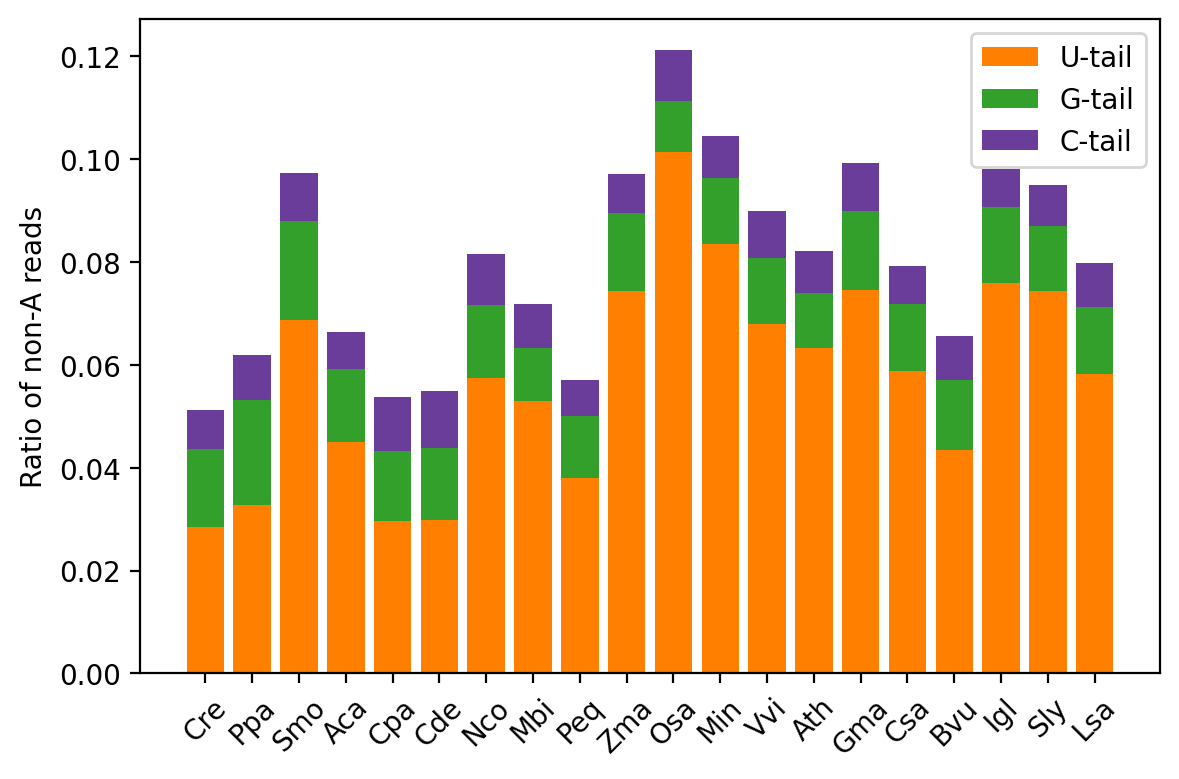

In [18]:
pivot = test.pivot(index='short_name', columns='type', values='ratio').reindex(x_order)

# 绘图
plt.figure(figsize=(6, 4))
bottom = pd.Series([0]*len(pivot), index=pivot.index)
for t in ['U-tail', 'G-tail', 'C-tail']:
    plt.bar(pivot.index, pivot[t], bottom=bottom, color=colors[t], label=t)
    bottom += pivot[t].fillna(0)

# 设置图形属性
plt.ylabel("Ratio of non-A reads")
plt.xticks(rotation=45)
plt.legend(title="")
plt.tight_layout()
plt.savefig("/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/output/UCG.ratio.stacked.svg", bbox_inches='tight')
plt.show()

## 2.3 1U-5U比例

In [19]:
data=pd.read_csv("/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/output/all_species_nonA_ratio.txt", sep="\t", na_values="NA")
data['short_name'] = data['species'].apply(extract_name)
test = data[data['type'].isin(['1U', '2U','3U',  '4U', '5U','>5U'])]

In [20]:
test.head()

,Unnamed: 0,type,count,ratio,species,short_name
1,1.0,1U,48193,0.032634214156232244,Cucumis sativus,Csa
2,2.0,2U,21523,0.01457444424054503,Cucumis sativus,Csa
4,4.0,3U,9849,0.006669316606659295,Cucumis sativus,Csa
6,6.0,>5U,3548,0.00240255206827365,Cucumis sativus,Csa
7,7.0,4U,2827,0.0019143220679283,Cucumis sativus,Csa


In [21]:
test["ratio"] = pd.to_numeric(test["ratio"], errors="coerce")

/tmp/ipykernel_71200/112726529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["ratio"] = pd.to_numeric(test["ratio"], errors="coerce")


In [24]:
test["count"] = pd.to_numeric(test["count"], errors="coerce")


/tmp/ipykernel_71200/861108602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["count"] = pd.to_numeric(test["count"], errors="coerce")


In [25]:
species_total = test.groupby("species")["count"].transform("sum")

# 2. 新增一列 new_ratio
test["new_ratio"] = test["count"] / species_total

/tmp/ipykernel_71200/326539946.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["new_ratio"] = test["count"] / species_total


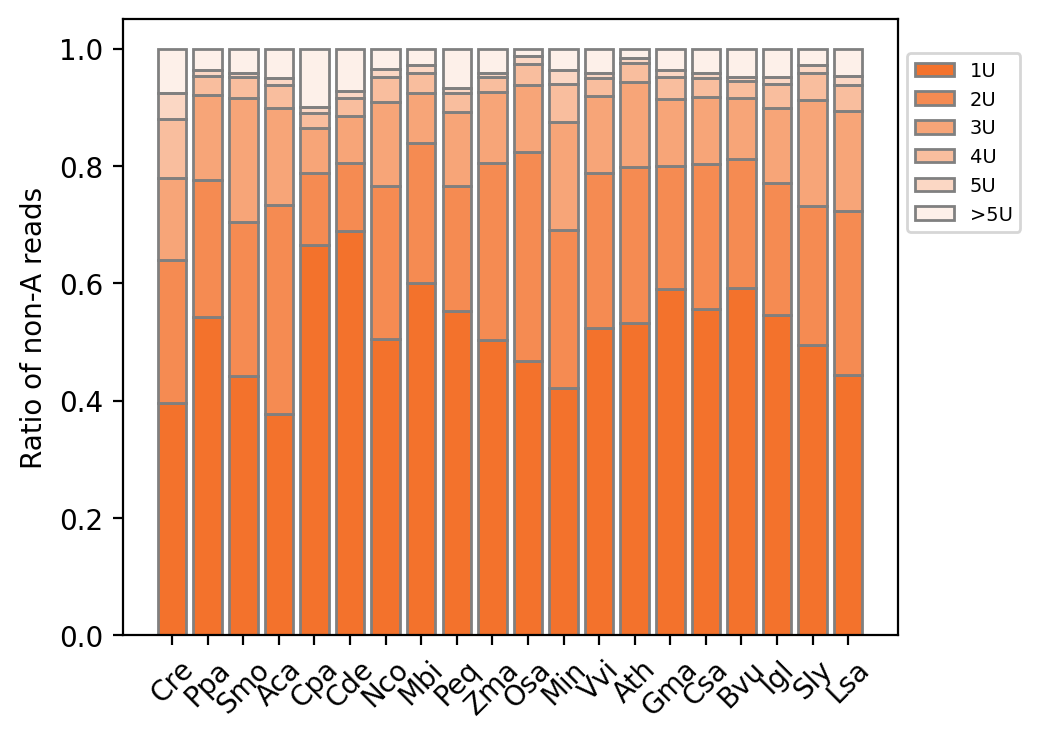

In [28]:
# 堆积顺序（1U 在底部，>5U 在顶部）
stack_order = ['1U', '2U', '3U', '4U', '5U', '>5U']

# 转换数据为适合堆积的格式
pivot_df = test.pivot_table(index="short_name", columns="type", values="new_ratio", aggfunc="sum")
pivot_df = pivot_df[stack_order] 
pivot_df = pivot_df.reindex(x_order)
#**使用橙色 (`#FFA500`) 并倒转透明度**
base_color = "#f3722c"  
alphas = np.linspace(1.0, 0.1, len(stack_order))  # **倒序透明度**（1U 最深，>5U 最浅）
colors = {t: (*plt.cm.colors.to_rgba(base_color)[:3], alpha) for t, alpha in zip(stack_order, alphas)}

# **绘制堆积柱状图**
plt.figure(figsize=(5, 4))
bottoms = None  # 记录底部位置
for category in stack_order:  # 遍历 stack_order，确保 1U 在底部，>5U 在顶部
    plt.bar(
        pivot_df.index, pivot_df[category], bottom=bottoms, label=category, 
        color=colors[category], edgecolor='gray', linewidth=1
    )
    bottoms = pivot_df[category] if bottoms is None else bottoms + pivot_df[category]

# **设置图例、标签**
plt.xlabel("")
plt.ylabel("Ratio of non-A reads")
plt.xticks(rotation=45)
plt.legend(title="", loc="center left", bbox_to_anchor=(1.0, 0.8),
           fontsize=7, frameon=True, markerscale=0.)

plt.savefig("/public/Zhaijx/cheny/project/01.polya-evo/01.nonA-peter/output/1u_5u.svg", bbox_inches='tight')


# **显示图**
plt.show()
